In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

DATA_DIR = Path("../Data")
CRYPTO_PRICE_FILE = DATA_DIR / "Crypto_Price_20240407.csv"
CRIX_PRICE_FILE = DATA_DIR / "new_crix.csv"
EVENT_DATES_FILE = DATA_DIR / "event_dates.csv"
OUTPUT_FILE = DATA_DIR / "crypto_and_crix_log_returns.csv"

EXCLUDED_TICKERS = ["DOGE", "RDD", "BLK", "FTC", "ETC", "VTC", "BTG"]

ANALYSIS_START_DATE = "2017-09-07"
ANALYSIS_END_DATE   = "2024-04-07"
MERGED_DATA_START_DATE = "2017-09-08"  # first date with a CRIX log return

event_dates = pd.read_csv(EVENT_DATES_FILE)
event_dates["event_date"] = pd.to_datetime(event_dates["event_date"])
EVENT_DATES = event_dates["event_date"].dt.strftime("%Y-%m-%d").tolist()



In [45]:
# Load daily crypto-price series, excluding tickers outside this analysis.
crypto_prices = pd.read_csv(CRYPTO_PRICE_FILE)
crypto_prices["Date"] = pd.to_datetime(crypto_prices["Date"])
crypto_prices = crypto_prices.set_index("Date").sort_index()
crypto_prices = crypto_prices.drop(columns=EXCLUDED_TICKERS)


# Restrict to study window
# crypto_prices = crypto_prices.loc[ANALYSIS_START_DATE:ANALYSIS_END_DATE]


# Panel log returns
numeric_crypto_prices = crypto_prices.apply(pd.to_numeric, errors="coerce")
crypto_log_returns = np.log(numeric_crypto_prices).diff()
crypto_log_returns = crypto_log_returns.replace([np.inf, -np.inf], 0.0)
crypto_log_returns = crypto_log_returns.fillna(0.0)
crypto_log_returns.index.name = "Date"

# Retain ETH's full observed history for the plot, rather than the
# CRIX-aligned analysis window used by the exported table.
eth_log_returns = np.log(numeric_crypto_prices["ETH"].dropna()).diff().dropna()

In [47]:
# Load CRIX index prices, reindex to complete daily calendar, restrict to study window
crix_raw = pd.read_csv(CRIX_PRICE_FILE)
crix_raw["Date"] = pd.to_datetime(crix_raw["date"])
crix_raw = crix_raw.drop(columns=["date"])
crix_raw = crix_raw.set_index("Date")


# Create full calendar and merge
full_calendar = pd.DataFrame(
    {
        "Date": pd.date_range(
            start=crix_raw.index.min(),
            end=crix_raw.index.max(),
        )
    }
)

crix_calendar = full_calendar.merge(
    crix_raw,
    left_on="Date",
    right_index=True,
    how="left",
)

crix_calendar = (
    crix_calendar
    .set_index("Date")
    .loc[ANALYSIS_START_DATE:ANALYSIS_END_DATE]
    .bfill()
)


crix_prices = crix_calendar["price"]
crix_log_returns = np.log(crix_prices).diff().iloc[1:]


# Replace CRIX returns that are exactly zero with BTC's return (backfilling artifacts)
zero_return_mask = crix_log_returns == 0
crix_log_returns.loc[zero_return_mask] = crypto_log_returns["BTC"].reindex(
    crix_log_returns.index
)[zero_return_mask]


# -------------------------------------------------------------------
# Merge crypto panel returns with CRIX returns
# -------------------------------------------------------------------


# Restrict crypto returns to merged data start date
all_log_returns = crypto_log_returns.loc[
    MERGED_DATA_START_DATE:ANALYSIS_END_DATE
].copy()


# Add CRIX log returns as a new column
all_log_returns["CRIX"] = crix_log_returns.reindex(
    all_log_returns.index
)


# Save one table of log returns: every coin in the source file plus CRIX.
all_log_returns.to_csv(OUTPUT_FILE)
print(f"Saved log-return dataset: {OUTPUT_FILE}")
print(f"Shape: {all_log_returns.shape}")
print(f"Columns: {list(all_log_returns.columns)}")

Saved log-return dataset: ../Data/crypto_and_crix_log_returns.csv
Shape: (2404, 10)
Columns: ['BTC', 'ETH', 'XRP', 'LTC', 'BCH', 'ZEC', 'BSV', 'DASH', 'XMR', 'CRIX']


In [48]:
# -------------------------------------------------------------------
# Plotting utilities
# -------------------------------------------------------------------

def plot_log_returns_with_events(
    crix_log_returns: pd.Series,
    eth_log_returns: pd.Series,
    event_dates: list[str],
    save_path: str | None = None,
) -> plt.Figure:
    """
    Plot CRIX and ETH daily log returns on one chart,
    with vertical markers at each event date.
    """
    plt.rcParams["font.family"] = "serif"  # closest to Times New Roman if not installed

    fig, ax = plt.subplots(figsize=(20, 6))

    ax.plot(crix_log_returns.index, crix_log_returns.values,
            color="orange", linewidth=2, label="CRIX log return")

    ax.plot(eth_log_returns.index, eth_log_returns.values,
            color="black", linewidth=2, alpha=0.5, label="ETH log return")

    for date in event_dates:
        ax.axvline(pd.to_datetime(date), color="blue", linestyle=":", linewidth=1)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

    ax.set_ylabel("Log return", fontsize=16)
    ax.tick_params(axis="both", labelsize=14)

    fig.patch.set_alpha(0)   # transparent figure background
    ax.set_facecolor("none")  # transparent axes background
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, transparent=True)

    plt.show()
    return fig

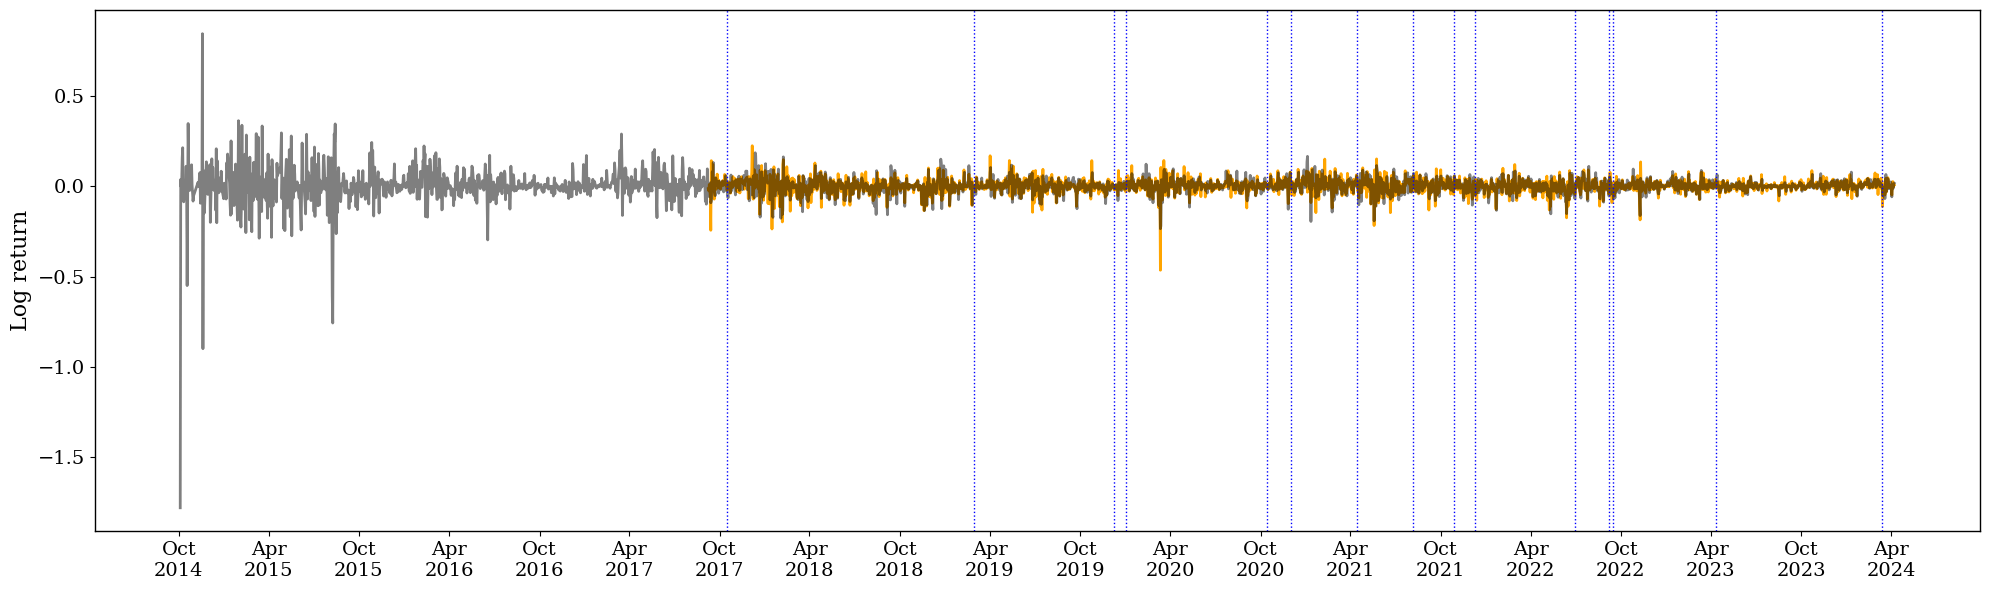

In [49]:
# --- Plot CRIX and ETH returns with events ---
fig = plot_log_returns_with_events(
        all_log_returns["CRIX"],
        eth_log_returns,
        EVENT_DATES,
        save_path="eth_crix_returns.png",
    )